<a href="https://colab.research.google.com/github/smcgovern-proj/neuromatch_ecog_project/blob/main/projects/ECoG/load_dataframes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading of Miller ECoG data of faces/houses (+ noise)

includes some visualizations

In [5]:
# @title Data retrieval
import os, requests

fname = 'faceshouses.npz'
url = "https://osf.io/argh7/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [1]:
# @title Install packages (`nilearn`, `nimare`), import `matplotlib` and set defaults
# install packages to visualize brains and electrode locations
!pip install nilearn --quiet
!pip install nimare --quiet
!pip install pandas
%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import rcParams
from matplotlib import pyplot as plt
rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.0/243.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 12.6 MB/s eta 0:00:00

In [10]:
# @title Helper Functions for Data Loading
import numpy as np
import pandas as pd

def get_channel_names(raw_data):
  V_uv = raw_data['V'] * raw_data['scale_uv'][np.newaxis, :]
  n_channels = V_uv.shape[1]
  channel_names = [f'ch{i}' for i in range(n_channels)]
  return channel_names

def set_up_voltage_df(raw_data):
  sampling_rate = raw_data["srate"].flatten()[0]
  V_uv = raw_data['V'] * raw_data['scale_uv'][np.newaxis, :]
  n_channels = V_uv.shape[1]
  channel_names = [f'ch{i}' for i in range(n_channels)]
  voltage_df = pd.DataFrame(V_uv, columns=channel_names)
  voltage_df['time'] = voltage_df.index / sampling_rate
  assert raw_data['V'].shape[1] == raw_data['locs'].shape[0], "channel dimension mismatch"
  return voltage_df

def set_up_trial_df(raw_data):
  trials_df = pd.DataFrame({
    't_on': raw_data['t_on'],
    't_off': raw_data['t_off'],
    'stim_id': raw_data['stim_id']
  })
  return trials_df

def set_up_channel_df(raw_data):
  channel_names = get_channel_names(raw_data)
  channels_df = pd.DataFrame({
    'x': raw_data['locs'][:, 0],
    'y': raw_data['locs'][:, 1],
    'z': raw_data['locs'][:, 2],
    'scale_uv': raw_data['scale_uv'],
    'hemisphere': raw_data['hemisphere'],
    'lobe': raw_data['lobe'],
    'gyrus': raw_data['gyrus'],
    'Brodmann_Area': raw_data['Brodmann_Area']
  }, index=channel_names)
  channels_df.index.name = 'channel'
  return channels_df



In [11]:
# @title Data loading
alldat = np.load(fname, allow_pickle=True)['dat']

# select just one of the recordings here.
dat1 = alldat[1][0]
dat2 = alldat[1][1]

#Setup df for voltage data
voltage_df = set_up_voltage_df(dat1)

#Setup df for trial data
trials_df = set_up_trial_df(dat1)

#Setup df for channel data
channels_df = set_up_channel_df(dat1)

#Log first ten rows of each df
print(voltage_df.head())
print("\n-----------------")
print(trials_df.head())
print("\n-----------------")
print(channels_df.head(50))

        ch0       ch1       ch2       ch3       ch4       ch5       ch6  \
0  0.492160  0.702628  0.700809  0.691527  0.590633  0.967717  0.305281   
1  0.219916  0.438187  0.422618  0.462583  0.352087  0.710202  0.022420   
2 -0.186591  0.030862  0.021734  0.073729 -0.029102  0.316498 -0.379900   
3 -0.625734 -0.414210 -0.402989 -0.379140 -0.450805 -0.117548 -0.804671   
4 -0.960084 -0.756837 -0.719225 -0.748893 -0.774647 -0.456764 -1.124321   

        ch7       ch8       ch9  ...      ch41      ch42      ch43      ch44  \
0  0.292482 -0.146774  0.196184  ...  0.051435  0.732595  0.267219 -0.136819   
1  0.003239 -0.439609 -0.072904  ... -0.246393  0.422934 -0.052307 -0.428061   
2 -0.407976 -0.855905 -0.480246  ... -0.661429 -0.020433 -0.478532 -0.816631   
3 -0.843724 -1.292184 -0.917953  ... -1.090701 -0.489010 -0.904497 -1.203338   
4 -1.173455 -1.616657 -1.247072  ... -1.399514 -0.837119 -1.189864 -1.454437   

       ch45      ch46      ch47      ch48      ch49   time  
0 -0.19

# Dataset info #

This is one of multiple ECoG datasets from Miller 2019, recorded in a clinical settings with a variety of tasks. We plan to curate a few more before NMA starts. Raw data here:

https://exhibits.stanford.edu/data/catalog/zk881ps0522

`alldat` contains 7 subjects each with two sessions `dat1` and `dat2`, and was originally used in these publications:

*Miller, Kai J., et al. "Face percept formation in human ventral temporal cortex." Journal of neurophysiology 118.5 (2017): 2614-2627.*

*Miller, Kai J., et al. "The physiology of perception in human temporal lobe is specialized for contextual novelty." Journal of neurophysiology 114.1 (2015): 256-263.*

*Miller, Kai J., et al. "Spontaneous decoding of the timing and content of human object perception from cortical surface recordings reveals complementary information in the event-related potential and broadband spectral change." PLoS computational biology 12.1 (2016): e1004660.*

*Miller, Kai J., et al. "The physiology of perception in human temporal lobe is specialized for contextual novelty." Journal of neurophysiology 114.1 (2015): 256-263.*

*Miller, Kai J., et al. "Spontaneous decoding of the timing and content of human object perception from cortical surface recordings reveals complementary information in the event-related potential and broadband spectral change." PLoS computational biology 12.1 (2016): e1004660.*

In this task, subjects in a clinical settings (with ECoG implants) are passively shown faces and house during the first experiment (`dat1`). Then in the second experiment in the same subjects (`dat2`), noise is added to face and houses images and the subject has to detect the faces by pressing a key. Two of the subjects don't have keypresses.

Sample rate is always 1000Hz, and the ECoG data has been notch-filtered at 60, 120, 180, 240 and 250Hz, followed by z-scoring across time and conversion to float16 to minimize size.

Experiment 1:
* `dat1['V']`: continuous voltage data (time by channels)
* `dat1['srate']`: acquisition rate (1000 Hz). All stimulus times are in units of this.  
* `dat1['t_on']`: time of stimulus onset in data samples
* `dat1['t_off']`: time of stimulus offset, always 400 samples after `t_on`
* `dat1['stim_id`]: identity of stimulus from 1-100, with 1-50 being houses and 51-100 being faces
* `dat1['locs`]: 3D electrode positions on the brain surface

Experiment 2:
* `dat2['V`]: continuous voltage data (time by channels)
* `dat2['srate']`: acquisition rate (1000 Hz). All stimulus times are in units of this.  
* `dat2['t_on']`: time of stimulus onset in data samples
* `dat2['t_off']`: time of stimulus offset, always 1000 samples after `t_on`, with no inter-stimulus interval
* `dat2['stim_id`]: identity of stimulus from 1-600 (not really useful, since we don't know which ones are the same house/face)
* `dat2['stim_cat']`: stimulus category (1 = house, 2 = face)
* `dat2['stim_noise']`: percent noise from 0 to 100
* `dat2['key_press']`: when the subject thought the image was a face
* `dat2['categories']`: categories legend (1 = house, 2 = face)
* `dat2['locs`]: 3D electrode positions on the brain surface


In [ ]:
from nilearn import plotting
from nimare import utils

plt.figure(figsize=(8, 8))
locs = dat1['locs']
view = plotting.view_markers(utils.tal2mni(locs),
                             marker_labels=['%d'%k for k in np.arange(locs.shape[0])],
                             marker_color='purple',
                             marker_size=5)
view

In [ ]:
# quick way to get broadband power in time-varying windows
from scipy import signal

V = dat1['V'].astype('float32')

b, a = signal.butter(3, [50], btype='high', fs=1000)
V = signal.filtfilt(b, a, V, 0)
V = np.abs(V)**2
b, a = signal.butter(3, [10], btype='low', fs=1000)
V = signal.filtfilt(b, a, V, 0)

V = V/V.mean(0)

In [ ]:
# average the broadband power across all face stimuli and across all house stimuli

nt, nchan = V.shape
nstim = len(dat1['t_on'])

trange = np.arange(-200, 400)
ts = dat1['t_on'][:, np.newaxis] + trange
V_epochs = np.reshape(V[ts, :], (nstim, 600, nchan))

V_house = (V_epochs[dat1['stim_id'] <= 50]).mean(0)
V_face = (V_epochs[dat1['stim_id'] > 50]).mean(0)
print(np.mean(V_house))
print(np.mean(V_face))

0.9878698326373075
0.9778905066783652


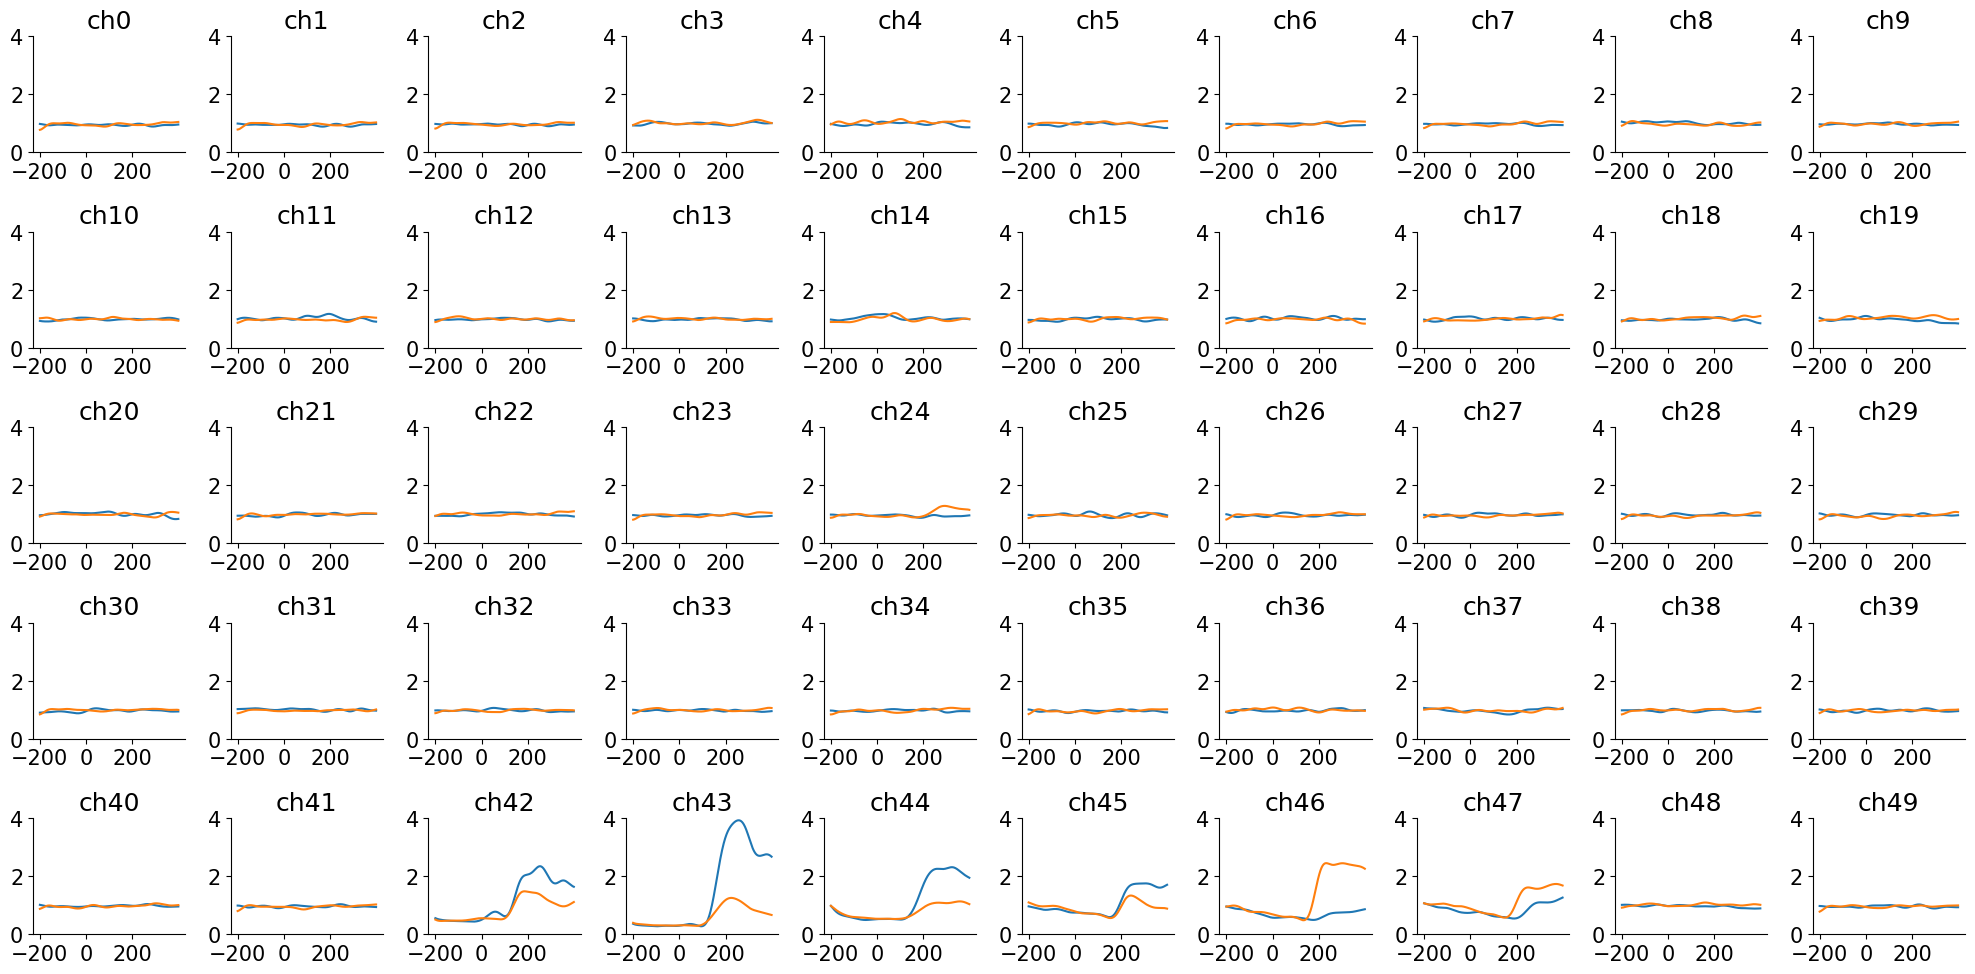

In [ ]:
# let's find the electrodes that distinguish faces from houses
plt.figure(figsize=(20, 10))
for j in range(50):
  ax = plt.subplot(5, 10, j+1)
  plt.plot(trange, V_house[:, j])
  plt.plot(trange, V_face[:, j])
  plt.title('ch%d'%j)
  plt.xticks([-200, 0, 200])
  plt.ylim([0, 4])
plt.show()

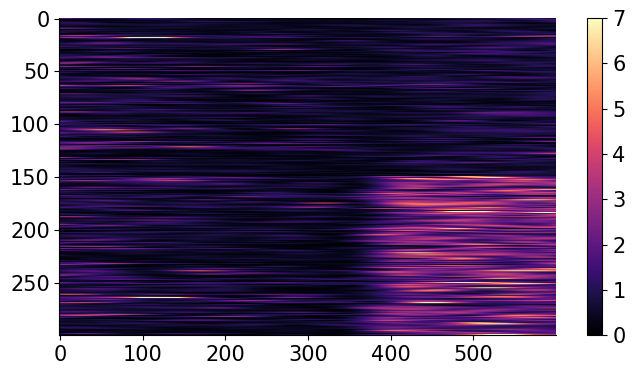

In [ ]:
# let's look at all the face trials for electrode 46 that has a good response to faces
# we will sort trials by stimulus id (1-50 is houses, 51-100 is faces)
plt.subplot(1, 3, 1)
isort = np.argsort(dat1['stim_id'])
plt.imshow(V_epochs[isort, :, 46].astype('float32'),
           aspect='auto', vmax=7, vmin=0,
           cmap='magma')
plt.colorbar()
plt.show()

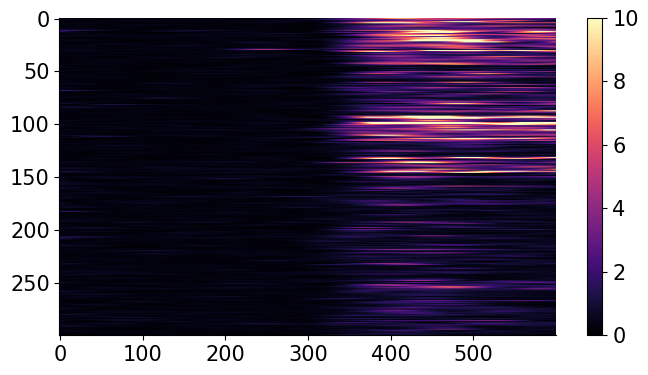

In [ ]:
# Electrode 43 seems to respond to houses
isort = np.argsort(dat1['stim_id'])
plt.subplot(1, 3, 1)
plt.imshow(V_epochs[isort, :, 43].astype('float32'),
           aspect='auto', vmax=10, vmin=0,
           cmap='magma')
plt.colorbar()
plt.show()